In [61]:
#BASELINE MODEL - logistic regression model for predicting management strategy, 81% baseline accuracy.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix)


In [74]:
#LOAD THE DATASET
data = pd.read_excel("/Users/simonwilliams/code/simonwilliams32/MRI_project/raw_data/synthetic_vestibular_schwannoma_data.xlsx")
data.head()

,age_at_diagnosis,Sex,BMI,tumour_laterality,Scan 1: Volume,linear_regression_growth_rate_cm3,charlson_comorbidity_index,koos_grade_at_presentation,Management
0,53,M,26.686467,R,97.735,-0.073669,0,1,SRS
1,66,F,28.385639,L,466.545,-0.204869,2,1,Surveillance
2,30,F,25.541945,R,182.759,-0.274673,0,1,Surveillance
3,57,F,NaN,R,0.000,NaN,0,1,SRS
4,59,M,26.573149,R,0.000,0.563720,2,4,SRS


In [67]:
#Train test split
X = data.drop(columns=["Management"])
y = data["Management"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [71]:
#BASELINE PREPROC PIPELINE
numeric_cols = ["BMI", "Scan 1: Volume", "linear_regression_growth_rate_cm3", "charlson_comorbidity_index", "age_at_diagnosis"]
categorical_cols = ["Sex", "koos_grade_at_presentation", "tumour_laterality"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        drop="if_binary",
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_cols),
    ("categorical", categorical_pipeline, categorical_cols)
])

# pipeline = Pipeline([
  #  ("preprocessor", preprocessor),
   # ("model") #ADD MODELL PARAMETERS HERE
#])

preprocessor

,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [55]:
#SVM
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
    kernel="rbf",
    C=50,
    gamma=0.01,
    probability=True,
    random_state=42
    ))
])

svm_cv_results = cross_validate(
    svm_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro"
    }
)

print("SVM Trial Run")
print("Mean CV accuracy:", svm_cv_results["test_accuracy"].mean())
print("Mean CV balanced accuracy:", svm_cv_results["test_balanced_accuracy"].mean())
print("Mean CV macro F1:", svm_cv_results["test_f1_macro"].mean())


SVM Trial Run
Mean CV accuracy: 0.8154999999999999
Mean CV balanced accuracy: 0.8208068553790417
Mean CV macro F1: 0.8228426425720938


In [46]:
#Random Forrest (note - hyperparameters have been gridsearched)
RF_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=380,
        max_depth=10,
        min_samples_split=4,
        random_state=42,
        n_jobs=-1
    ))
])

RF_cv_results = cross_validate(
    RF_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro"
    }
)

print("RF Trial Run")
print("Mean CV accuracy:", RF_cv_results["test_accuracy"].mean())
print("Mean CV balanced accuracy:", RF_cv_results["test_balanced_accuracy"].mean())
print("Mean CV macro F1:", RF_cv_results["test_f1_macro"].mean())


RF Trial Run
Mean CV accuracy: 0.8255000000000001
Mean CV balanced accuracy: 0.8313693323919924
Mean CV macro F1: 0.832487374417302


In [23]:
#K Nearest Neighbour

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(
        n_neighbors=10
    ))
])

knn_cv_results = cross_validate(
    knn_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro"
    }
)

print("KNN Trial Run")
print("Mean CV accuracy:", knn_cv_results["test_accuracy"].mean())
print("Mean CV balanced accuracy:", knn_cv_results["test_balanced_accuracy"].mean())
print("Mean CV macro F1:", knn_cv_results["test_f1_macro"].mean())


KNN Trial Run
Mean CV accuracy: 0.7939999999999999
Mean CV balanced accuracy: 0.7991399189931917
Mean CV macro F1: 0.8008264356985307


In [33]:
#XGBoost

# Encode target labels as integers as wont work otherwise for xgb
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

XGB_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    ))
])

XGB_cv_results = cross_validate(
    XGB_pipeline,
    X_train,
    y_train_encoded,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro"
    }
)

print("XGBoost Trial Run")
print("Mean CV accuracy:", XGB_cv_results["test_accuracy"].mean())
print("Mean CV balanced accuracy:", XGB_cv_results["test_balanced_accuracy"].mean())
print("Mean CV macro F1:", XGB_cv_results["test_f1_macro"].mean())


XGBoost Trial Run
Mean CV accuracy: 0.80525
Mean CV balanced accuracy: 0.8111810167733976
Mean CV macro F1: 0.8129859122659646


In [ ]:
#LogReg (hyperparameter tuned C)

log_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        C=0.1
    ))
])

log_cv_results = cross_validate(
    log_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro"
    }
)

print("LogReg Trial Run")
print("Mean CV accuracy:", log_cv_results["test_accuracy"].mean())
print("Mean CV balanced accuracy:", log_cv_results["test_balanced_accuracy"].mean())
print("Mean CV macro F1:", log_cv_results["test_f1_macro"].mean())


LogReg Trial Run
Mean CV accuracy: 0.81425
Mean CV balanced accuracy: 0.8192620771962276
Mean CV macro F1: 0.8221820706159033


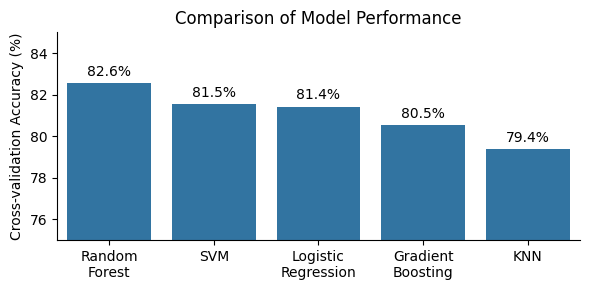

In [69]:
# Mean CV accuracies (convert to percentages)
results = pd.DataFrame({
    "Model": [
        "Logistic\nRegression",
        "SVM",
        "Random\nForest",
        "KNN",
        "Gradient\nBoosting"
    ],
    "Accuracy": [
        log_cv_results["test_accuracy"].mean() * 100,
        svm_cv_results["test_accuracy"].mean() * 100,
        RF_cv_results["test_accuracy"].mean() * 100,
        knn_cv_results["test_accuracy"].mean() * 100,
        XGB_cv_results["test_accuracy"].mean() * 100
    ]
})

# Sort from best to worst
results = results.sort_values("Accuracy", ascending=False)

plt.figure(figsize=(6, 3))

ax = sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

# Add accuracy labels above bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.ylim(75, 85)
plt.ylabel("Cross-validation Accuracy (%)")
plt.xlabel("")
plt.title("Comparison of Model Performance")
sns.despine()
plt.tight_layout()
plt.show()

In [70]:
#Creating a stacked ensemble model pipeline that vote

ensemble_model = VotingClassifier(
    estimators=[("logistic_regression", log_pipeline), ("svm", svm_pipeline), ("random_forest", RF_pipeline), ("knn", knn_pipeline), ("xgboost", XGB_pipeline)],
    voting="soft",       #soft rather than hard voting = based on confidence rather than single vote
    weights=None,
    n_jobs=-1
)
ensemble_model

,estimators,"[('logistic_regression', ...), ('svm', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,-1
,flatten_transform,True
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None


In [ ]:
#CV results of ensemble model
ensemble_cv_results = cross_validate(ensemble_model, X_train, y_train, cv=5,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro"
    },
    n_jobs=-1
)
print("Soft-Voting Ensemble Cross-Validation Results")
print("Mean CV accuracy:", ensemble_cv_results["test_accuracy"].mean())
print("Mean CV balanced accuracy:", ensemble_cv_results["test_balanced_accuracy"].mean())
print("Mean CV macro F1:", ensemble_cv_results["test_f1_macro"].mean())

#TRAIN
ensemble_model.fit(X_train, y_train)

#TEST
y_pred_ensemble = ensemble_model.predict(X_test)
y_pred_proba_ensemble = ensemble_model.predict_proba(X_test)
ensemble_test_accuracy = accuracy_score(y_test, y_pred_ensemble)
ensemble_test_balanced_accuracy = balanced_accuracy_score(y_test, y_pred_ensemble)
ensemble_test_f1_macro = f1_score(y_test, y_pred_ensemble, average="macro")

print("\nSoft-Voting Ensemble Test Results")
print("Test accuracy:", ensemble_test_accuracy)
print("Test balanced accuracy:", ensemble_test_balanced_accuracy)
print("Test macro F1:", ensemble_test_f1_macro)

print("\nClassification Report")
print(classification_report(
        y_test,
        y_pred_ensemble
    )
)

Soft-Voting Ensemble Cross-Validation Results
Mean CV accuracy: 0.8200000000000001
Mean CV balanced accuracy: 0.8261766358657321
Mean CV macro F1: 0.8273819277789084

Soft-Voting Ensemble Test Results
Test accuracy: 0.818
Test balanced accuracy: 0.8226279483395232
Test macro F1: 0.8231398222712251

Classification Report
              precision    recall  f1-score   support

         SRS       0.80      0.72      0.76       357
     Surgery       0.91      0.89      0.90       279
Surveillance       0.77      0.86      0.81       364

    accuracy                           0.82      1000
   macro avg       0.83      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000



In [73]:
from pathlib import Path

print(Path(__file__))


NameError: name '__file__' is not defined

In [ ]:
now = datetime.now()
f = now.strftime("%d_%H_%M")
username = os.getlogin()
model_name = username+"_"+f
model_name